In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

# Visualization Style

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv("datset/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Dataset Shape :", df.shape)


Dataset Shape : (303, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

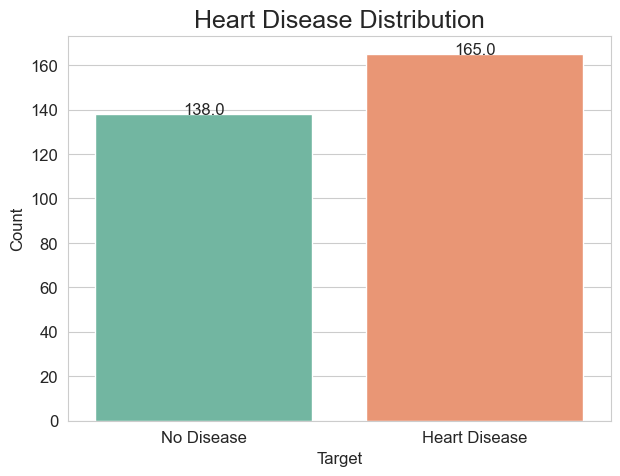

In [8]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='target',
    data=df,
    palette='Set2'
)

for p in ax.patches:
    
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        fontsize=12
    )

plt.xticks(
    [0,1],
    ['No Disease', 'Heart Disease']
)

plt.title("Heart Disease Distribution", fontsize=18)

plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

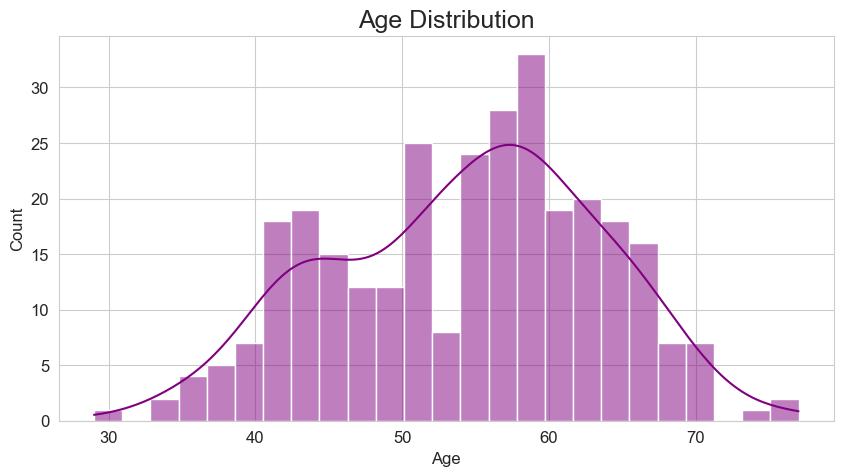

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=25,
    kde=True,
    color='purple'
)

plt.title("Age Distribution", fontsize=18)

plt.xlabel("Age")

plt.show()

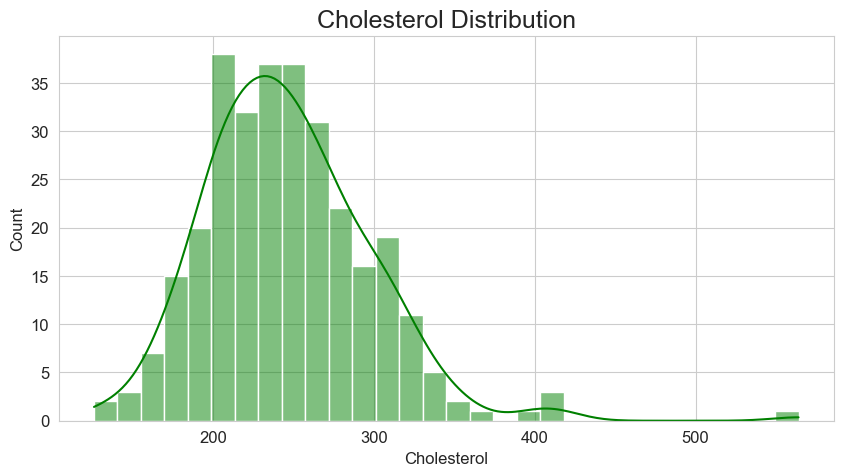

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['chol'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Cholesterol Distribution", fontsize=18)

plt.xlabel("Cholesterol")

plt.show()

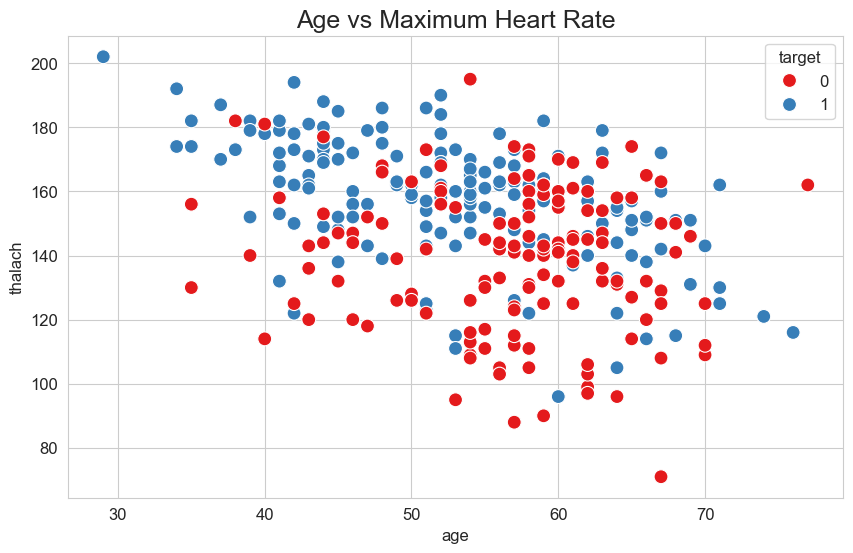

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='age',
    y='thalach',
    hue='target',
    data=df,
    palette='Set1',
    s=100
)

plt.title("Age vs Maximum Heart Rate", fontsize=18)

plt.show()

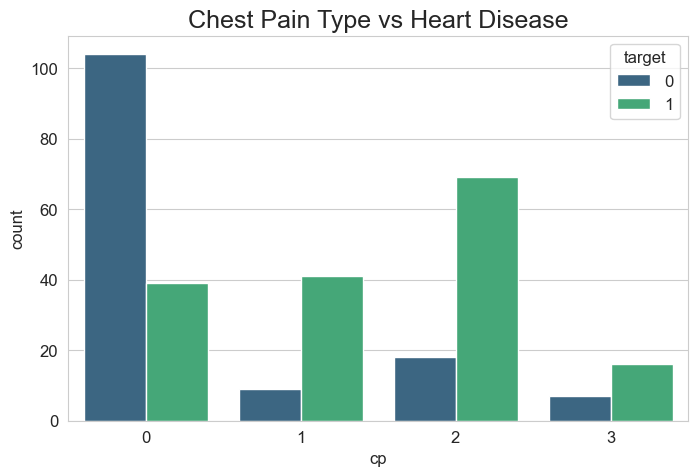

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='cp',
    hue='target',
    data=df,
    palette='viridis'
)

plt.title("Chest Pain Type vs Heart Disease", fontsize=18)

plt.show()

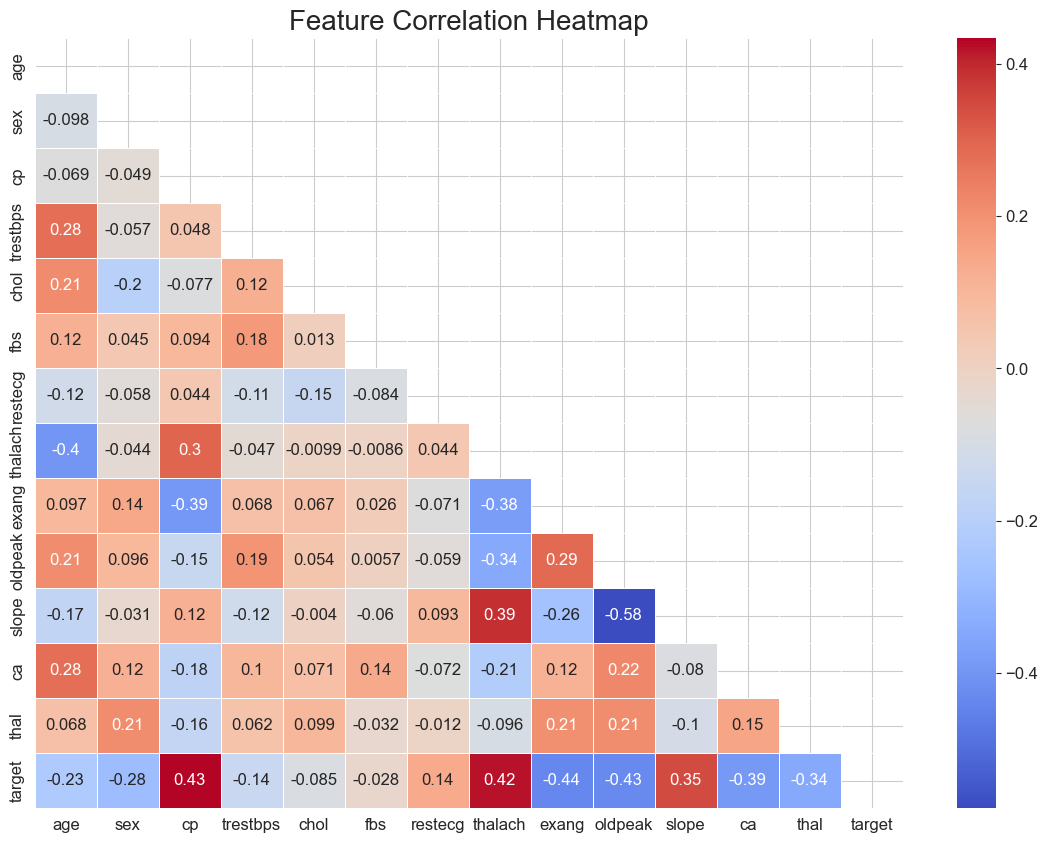

In [13]:
plt.figure(figsize=(14,10))

corr = df.corr()

mask = np.triu(np.ones_like(corr))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=20)

plt.show()

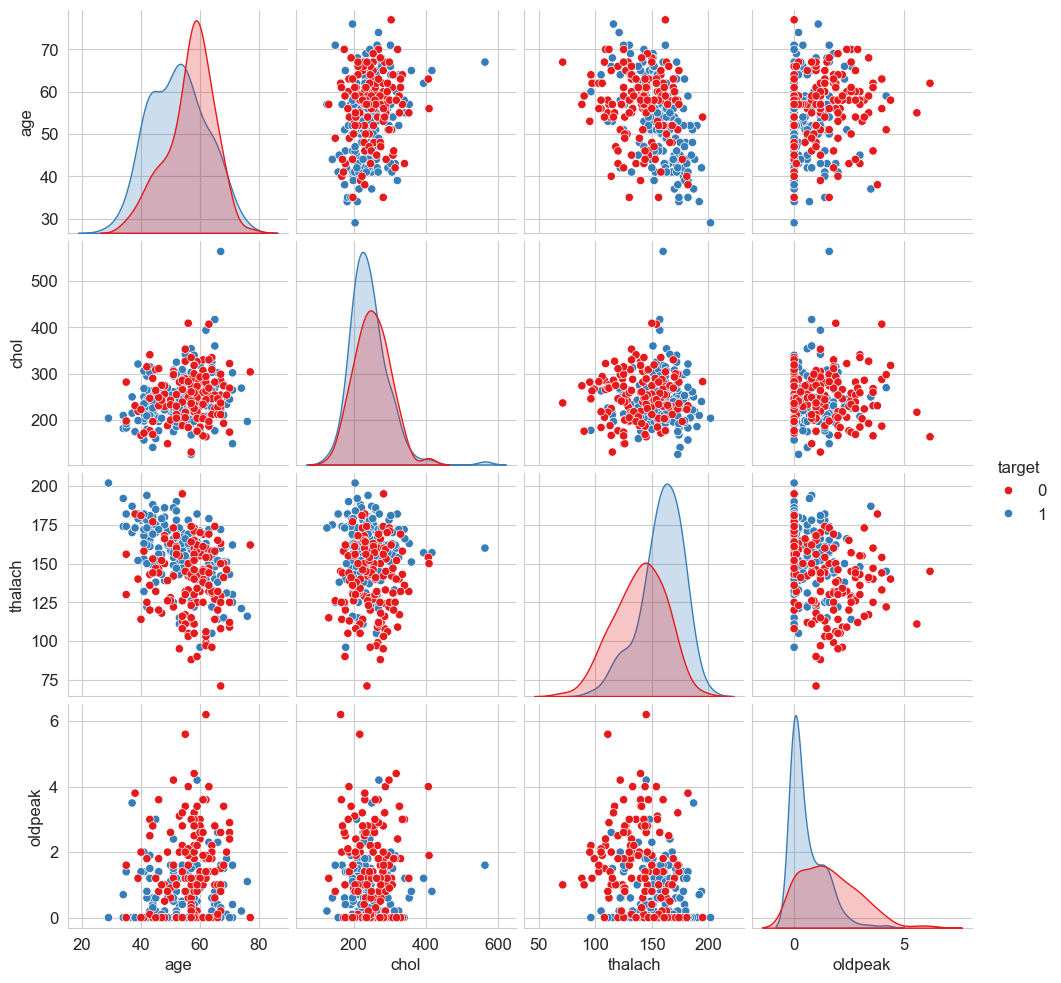

In [14]:
sns.pairplot(
    df[
        [
            'age',
            'chol',
            'thalach',
            'oldpeak',
            'target'
        ]
    ],
    hue='target',
    palette='Set1'
)

plt.show()

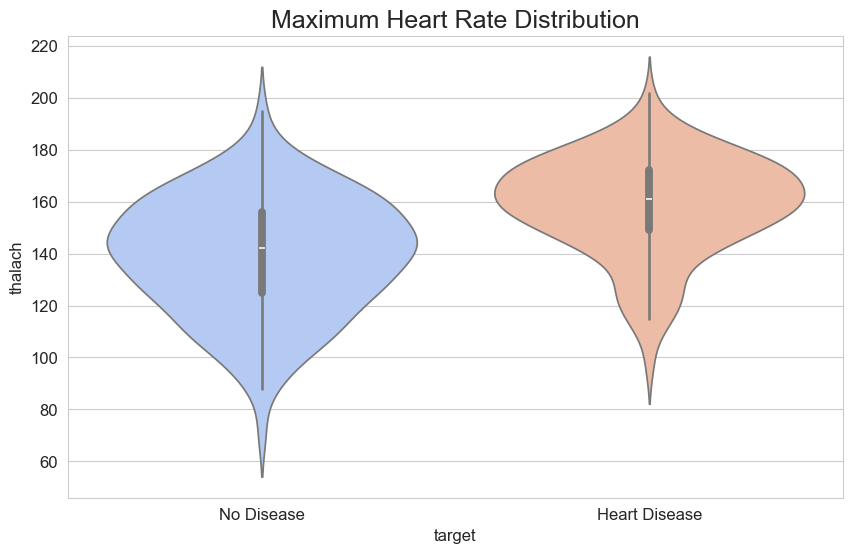

In [15]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='target',
    y='thalach',
    data=df,
    palette='coolwarm'
)

plt.xticks(
    [0,1],
    ['No Disease', 'Heart Disease']
)

plt.title("Maximum Heart Rate Distribution", fontsize=18)

plt.show()

In [16]:
X = df.drop('target', axis=1)

y = df['target']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8032786885245902


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.819672131147541


In [21]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.819672131147541


In [22]:
models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    
    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.803279
1,Random Forest,0.819672
2,KNN,0.819672


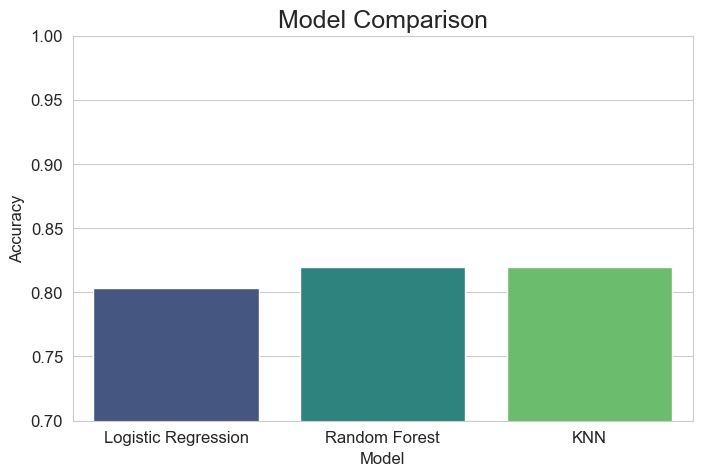

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models,
    palette='viridis'
)

plt.title("Model Comparison", fontsize=18)

plt.ylim(0.7,1.0)

plt.show()

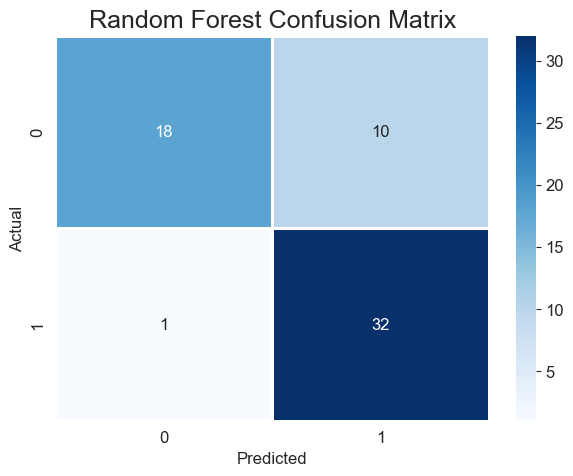

In [24]:
plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1
)

plt.title("Random Forest Confusion Matrix", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



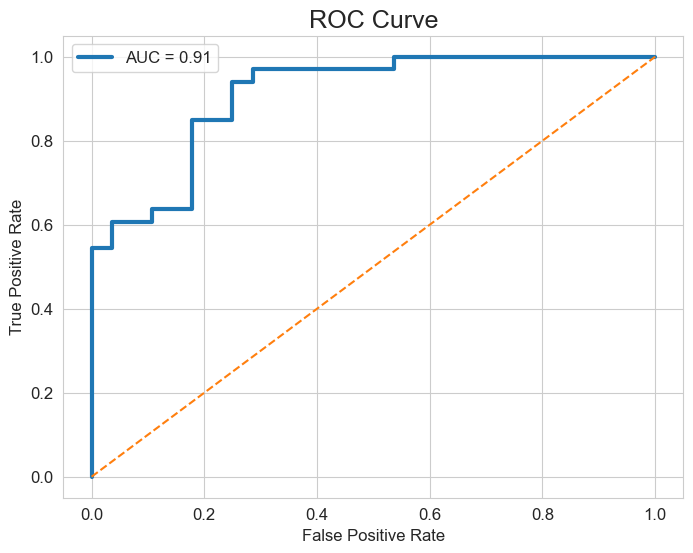

In [26]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

auc_score = roc_auc_score(
    y_test,
    rf_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'AUC = {auc_score:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve", fontsize=18)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,cp,0.167507
12,thal,0.125401
7,thalach,0.109336
9,oldpeak,0.108145
11,ca,0.091233
8,exang,0.075388
4,chol,0.075101
0,age,0.073947
3,trestbps,0.063651
10,slope,0.057802


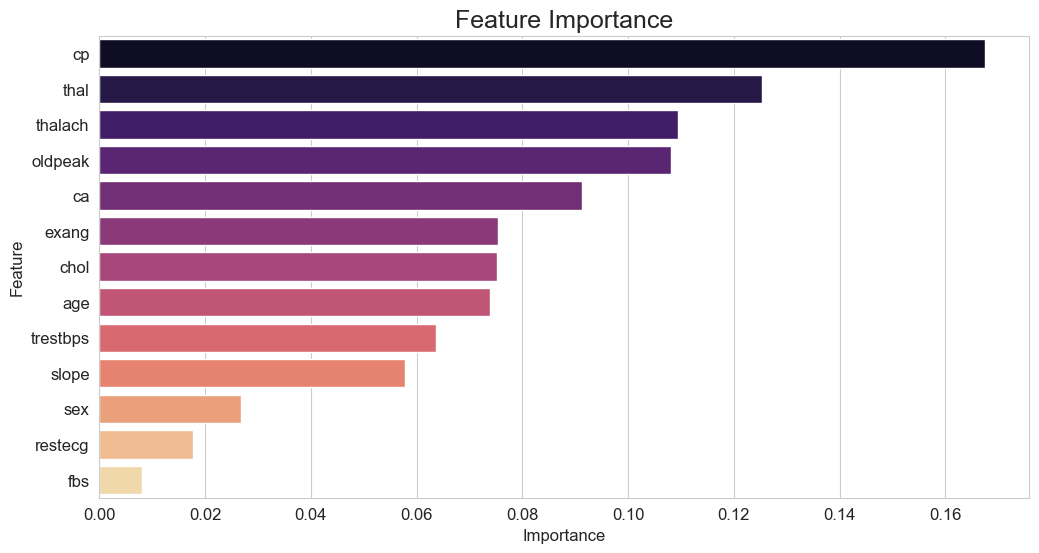

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='magma'
)

plt.title("Feature Importance", fontsize=18)

plt.show()

In [29]:
contingency_table = pd.crosstab(
    df['cp'],
    df['target']
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic :", chi2)

print("P-value :", p_value)

Chi-Square Statistic : 81.68642755194445
P-value : 1.3343043373050064e-17


In [30]:
alpha = 0.05

if p_value < alpha:
    
    print("Reject Null Hypothesis")
    print("Chest pain type affects heart disease.")
    
else:
    
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
Chest pain type affects heart disease.
